11th day **assingment**

In [2]:
!pip uninstall -y diffusers transformers accelerate huggingface_hub tokenizers peft

!pip install \
torch torchvision torchaudio \
transformers==4.38.2 \
diffusers==0.27.2 \
accelerate==0.27.2 \
huggingface_hub==0.20.3 \
peft==0.9.0 \
sentencepiece


Found existing installation: diffusers 0.27.2
Uninstalling diffusers-0.27.2:
  Successfully uninstalled diffusers-0.27.2
Found existing installation: transformers 4.38.2
Uninstalling transformers-4.38.2:
  Successfully uninstalled transformers-4.38.2
Found existing installation: accelerate 0.27.2
Uninstalling accelerate-0.27.2:
  Successfully uninstalled accelerate-0.27.2
Found existing installation: huggingface-hub 0.20.3
Uninstalling huggingface-hub-0.20.3:
  Successfully uninstalled huggingface-hub-0.20.3
Found existing installation: tokenizers 0.15.2
Uninstalling tokenizers-0.15.2:
  Successfully uninstalled tokenizers-0.15.2
Found existing installation: peft 0.18.1
Uninstalling peft-0.18.1:
  Successfully uninstalled peft-0.18.1
  Using cached transformers-4.38.2-py3-none-any.whl.metadata (130 kB)
  Using cached diffusers-0.27.2-py3-none-any.whl.metadata (18 kB)
  Using cached accelerate-0.27.2-py3-none-any.whl.metadata (18 kB)
  Using cached huggingface_hub-0.20.3-py3-none-any.wh

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

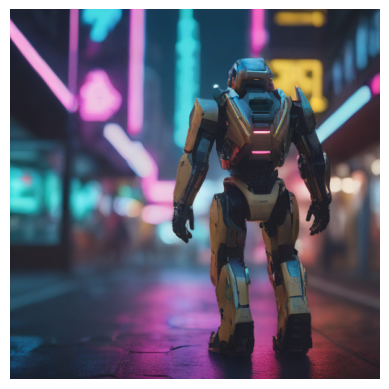

In [1]:
import torch
from diffusers import AutoPipelineForText2Image
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model_id = "stabilityai/sdxl-turbo"

pipe = AutoPipelineForText2Image.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if device=="cuda" else torch.float32,
    variant="fp16" if device=="cuda" else None
)

pipe.to(device)

prompt = "A futuristic robot walking in neon cyberpunk city, cinematic lighting"

image = pipe(prompt, num_inference_steps=2, guidance_scale=0.0).images[0]

plt.imshow(image)
plt.axis("off")
plt.show()
